In [1]:
import numpy as np
import torch
import math

In [2]:
def attention_partA(Q, K, V):
    # Q, K, V are B, Nh, T(seq Length) or N, D(head dimension)  
    Qk = torch.matmul(Q, K.transpose(-1, -2)) / math.sqrt(Q.size(-1))
    Qk = torch.softmax(Qk, dim=-1)
    O = torch.matmul(Qk, V)

    return O

In [3]:
B = 8
Nh = 16
D = 64
N = 2048
    
Q = torch.rand(size=(B, Nh, N, D), dtype=torch.float16, device="cuda")
K = torch.rand(size=(B, Nh, N, D), dtype=torch.float16, device="cuda")
V = torch.rand(size=(B, Nh, N, D), dtype=torch.float16, device="cuda")

start = torch.cuda.Event(enable_timing=True)
end = torch.cuda.Event(enable_timing=True)

torch.cuda.synchronize()

start.record()
O = attention_partA(Q, K, V)
end.record()
torch.cuda.synchronize()

time = start.elapsed_time(end)
print(f"time eplased in ms: {time:.2f}")
N *= 2
    

time eplased in ms: 341.97


In [4]:
def attention_partB(Q, K, V):
    # FlashAttention-style tiled implementation

    B, Nh, N, Hs = Q.size()

    # tile sizes
    M = 32 * 1024
    Bc = M // (4 * Hs)
    Br = min(Bc, Hs)

    Tc = (N + Bc - 1) // Bc
    Tr = (N + Br - 1) // Br

    # reshape to merge batch + heads
    Q = Q.reshape(B * Nh, N, Hs)
    K = K.reshape(B * Nh, N, Hs)
    V = V.reshape(B * Nh, N, Hs)

    # fp32 accumulators (important)
    m = torch.full((B * Nh, N), float('-inf'), device=Q.device, dtype=torch.float32)
    l = torch.zeros((B * Nh, N), device=Q.device, dtype=torch.float32)
    O = torch.zeros((B * Nh, N, Hs), device=Q.device, dtype=torch.float32)

    for j in range(Tc):
        Kj = K[:, j*Bc:(j+1)*Bc].float()   # [B*Nh, Bc, Hs]
        Vj = V[:, j*Bc:(j+1)*Bc].float()

        for i in range(Tr):
            Qi = Q[:, i*Br:(i+1)*Br].float()   # [B*Nh, Br, Hs]

            # attention scores
            Sij = torch.matmul(Qi, Kj.transpose(-1, -2)) / math.sqrt(Hs)

            # row-wise max
            mij = torch.max(Sij, dim=2).values   # [B*Nh, Br]

            # exp normalized
            Pij = torch.exp(Sij - mij.unsqueeze(2))
            lij = torch.sum(Pij, dim=2)          # [B*Nh, Br]

            # old stats
            m_old = m[:, i*Br:(i+1)*Br]
            l_old = l[:, i*Br:(i+1)*Br]
            Oi    = O[:, i*Br:(i+1)*Br]

            # new stats
            m_new = torch.maximum(m_old, mij)

            l_new = (
                torch.exp(m_old - m_new) * l_old
                + torch.exp(mij - m_new) * lij
            )

            # weighted values
            PV = torch.matmul(Pij, Vj)   # [B*Nh, Br, Hs]

            # output update
            O_new = (
                torch.exp(m_old - m_new).unsqueeze(2) * l_old.unsqueeze(2) * Oi
                + torch.exp(mij - m_new).unsqueeze(2) * PV
            ) / l_new.unsqueeze(2)

            # write back
            m[:, i*Br:(i+1)*Br] = m_new
            l[:, i*Br:(i+1)*Br] = l_new
            O[:, i*Br:(i+1)*Br] = O_new

    # reshape back
    O = O.reshape(B, Nh, N, Hs)

    return O.to(Q.dtype)

In [5]:
B, Nh, N, D = 8, 16, 512, 64

Q = torch.rand((B, Nh, N, D), device="cuda", dtype=torch.float16)
K = torch.rand((B, Nh, N, D), device="cuda", dtype=torch.float16)
V = torch.rand((B, Nh, N, D), device="cuda", dtype=torch.float16)

O1 = attention_partA(Q, K, V)
O2 = attention_partB(Q, K, V)

print(torch.allclose(O1.float(), O2.float(), atol=1e-2, rtol=1e-2))

True


In [6]:
import torch.nn.functional as F

def attention_partC(Q, K, V):
    return F.scaled_dot_product_attention(
        Q, K, V,
        attn_mask=None,
        dropout_p=0.0,
        is_causal=False
    )

In [7]:
O1 = attention_partA(Q, K, V)
O2 = attention_partB(Q, K, V)
O3 = attention_partC(Q, K, V)

print(torch.allclose(O1.float(), O2.float(), atol=1e-2, rtol=1e-2))
print(torch.allclose(O2.float(), O3.float(), atol=1e-2, rtol=1e-2))

True
True


N = 64
True
True
N = 128
True
True
N = 256
True
True
N = 512
True
True
N = 1024
True
True
N = 2048
True
True
N = 4096
True
True


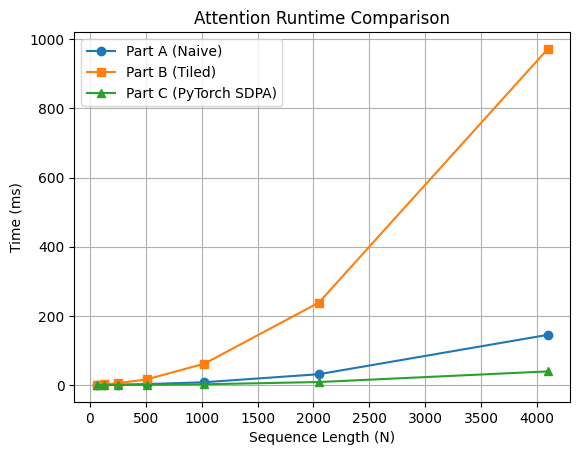

In [9]:
import torch
import time
import matplotlib.pyplot as plt

def benchmark():
    B, Nh, D = 8, 16, 64

    Ns = []
    t1, t2, t3 = [], [], []

    N = 64
    while N <= 4096:
        print(f"N = {N}")

        Q = torch.rand((B, Nh, N, D), device="cuda", dtype=torch.float16)
        K = torch.rand((B, Nh, N, D), device="cuda", dtype=torch.float16)
        V = torch.rand((B, Nh, N, D), device="cuda", dtype=torch.float16)

        # warmup
        for _ in range(3):
            attention_partA(Q, K, V)
            attention_partB(Q, K, V)
            attention_partC(Q, K, V)
        torch.cuda.synchronize()

        runs = 5

        # Part A
        total = 0
        for _ in range(runs):
            torch.cuda.synchronize()
            start = time.perf_counter()
            attention_partA(Q, K, V)
            torch.cuda.synchronize()
            total += time.perf_counter() - start
        t1.append(total / runs)

        # Part B
        total = 0
        for _ in range(runs):
            torch.cuda.synchronize()
            start = time.perf_counter()
            attention_partB(Q, K, V)
            torch.cuda.synchronize()
            total += time.perf_counter() - start
        t2.append(total / runs)

        # Part C
        total = 0
        for _ in range(runs):
            torch.cuda.synchronize()
            start = time.perf_counter()
            attention_partC(Q, K, V)
            torch.cuda.synchronize()
            total += time.perf_counter() - start
        t3.append(total / runs)

        # correctness check
        O1 = attention_partA(Q, K, V)
        O2 = attention_partB(Q, K, V)
        O3 = attention_partC(Q, K, V)

        print(torch.allclose(O1.float(), O2.float(), atol=1e-2, rtol=1e-2))
        print(torch.allclose(O2.float(), O3.float(), atol=1e-2, rtol=1e-2))

        Ns.append(N)
        N *= 2

    return Ns, t1, t2, t3


def plot_results(Ns, t1, t2, t3):
    # convert to ms
    t1 = [x * 1000 for x in t1]
    t2 = [x * 1000 for x in t2]
    t3 = [x * 1000 for x in t3]

    plt.figure()

    plt.plot(Ns, t1, marker='o', label='Part A (Naive)')
    plt.plot(Ns, t2, marker='s', label='Part B (Tiled)')
    plt.plot(Ns, t3, marker='^', label='Part C (PyTorch SDPA)')

   
    plt.xlabel("Sequence Length (N)")
    plt.ylabel("Time (ms)")
    plt.title("Attention Runtime Comparison")

    plt.legend()
    plt.grid()

    plt.savefig("attention_benchmark.png", dpi=300)
    plt.show()


# run everything
Ns, t1, t2, t3 = benchmark()
plot_results(Ns, t1, t2, t3)